In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display basic information
print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check the dataset
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df["Churn"].value_counts())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

In [4]:
# Clean the dataset

# Remove customer ID because it is only an identifier
df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric
# Invalid/blank values will become missing (NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values after conversion
print("Missing values:")
print(df.isnull().sum())

# Fill missing TotalCharges with the median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("\nCleaning completed!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Missing values:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Cleaning completed!
Rows: 7043
Columns: 20


In [5]:
# Basic statistics for numerical columns
print("Numerical summary:")
display(df.describe())

# Check unique values in categorical columns
print("\nUnique values in each column:")
for column in df.columns:
    print(column, ":", df[column].nunique())

Numerical summary:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000



Unique values in each column:
gender : 2
SeniorCitizen : 2
Partner : 2
Dependents : 2
tenure : 73
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
MonthlyCharges : 1585
TotalCharges : 6531
Churn : 2


Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


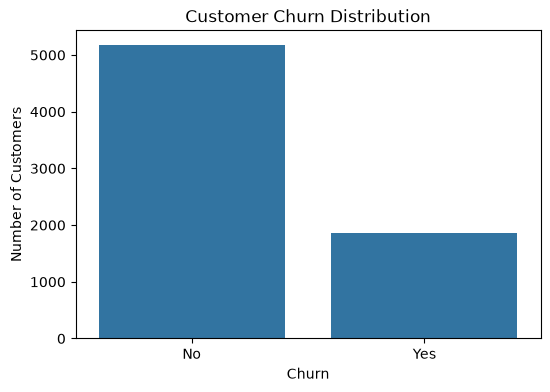

In [6]:
# Churn distribution

print("Churn counts:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

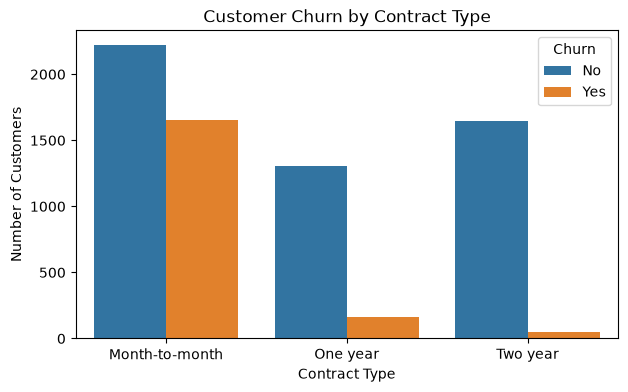

In [7]:
# Churn by contract type

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

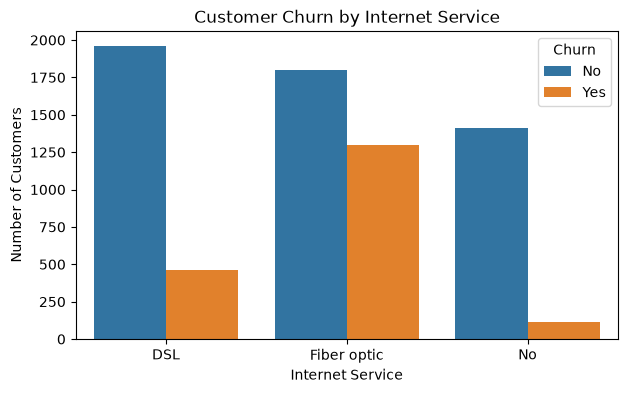

In [8]:
# Churn by Internet Service

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()


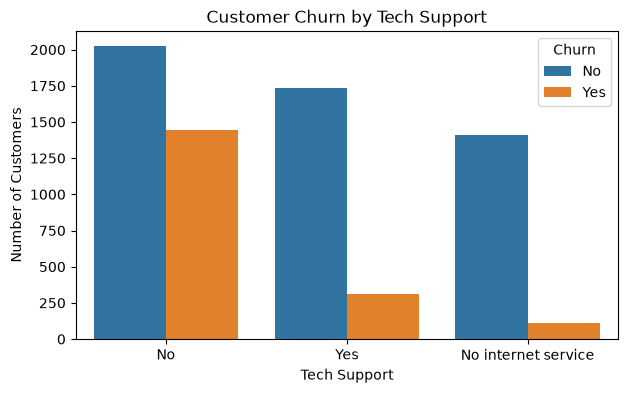

In [9]:
# Churn by Tech Support

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

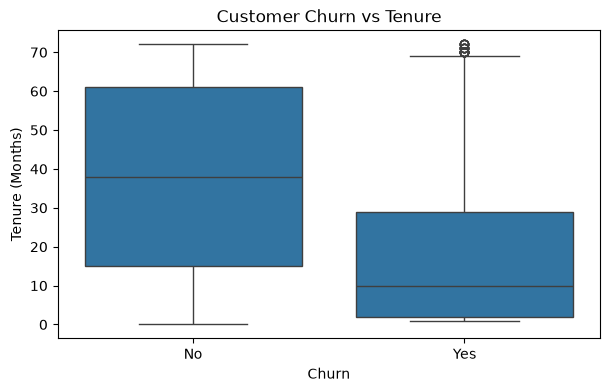

In [10]:
# Churn vs Customer Tenure

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Churn vs Tenure")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

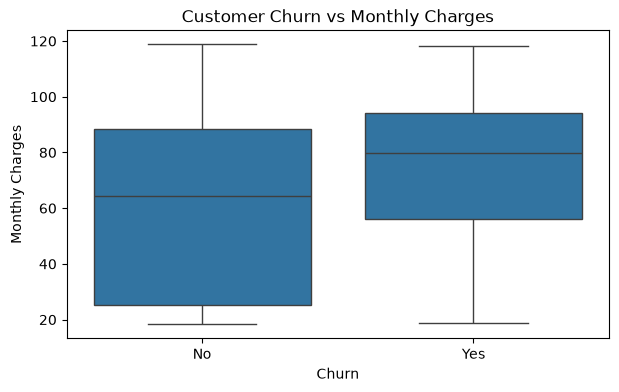

In [11]:
# Churn vs Monthly Charges

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Customer Churn vs Monthly Charges")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

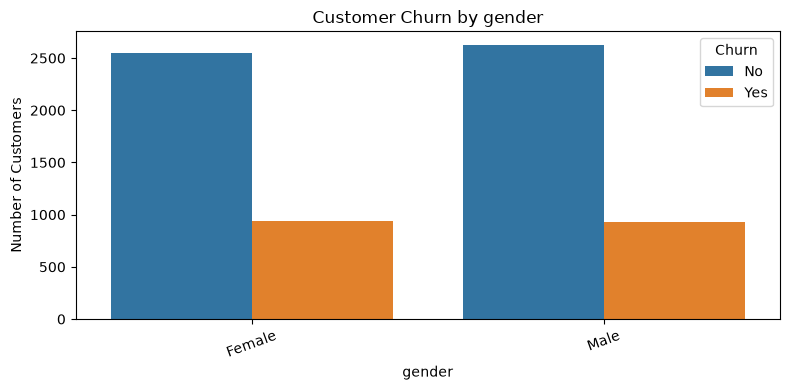

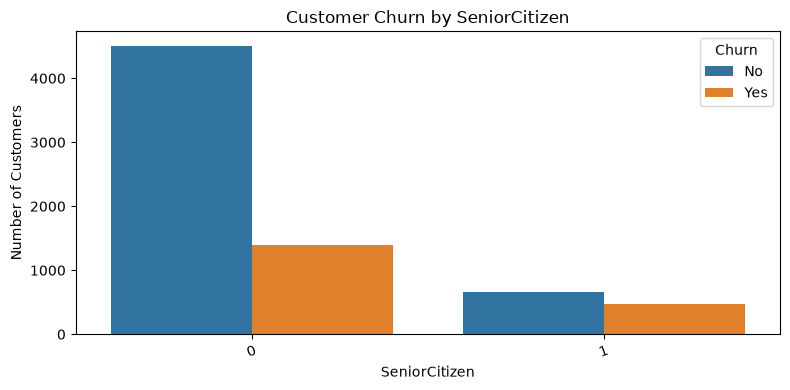

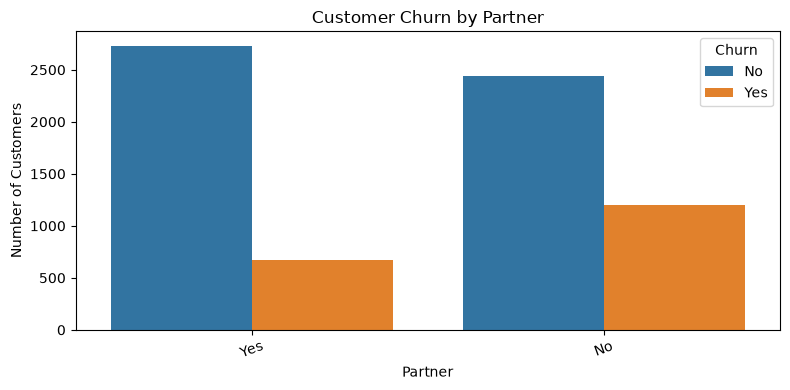

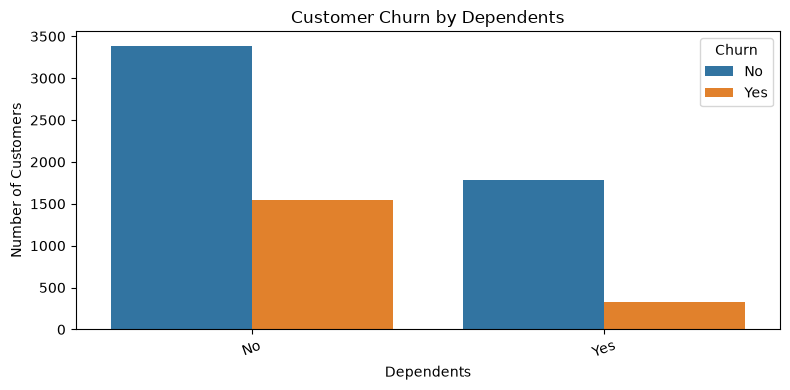

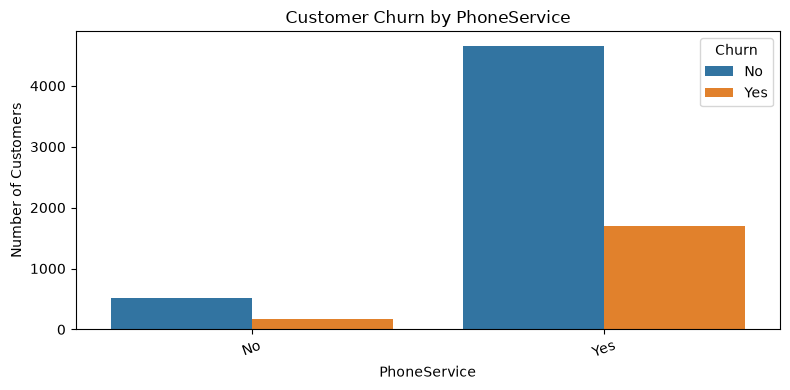

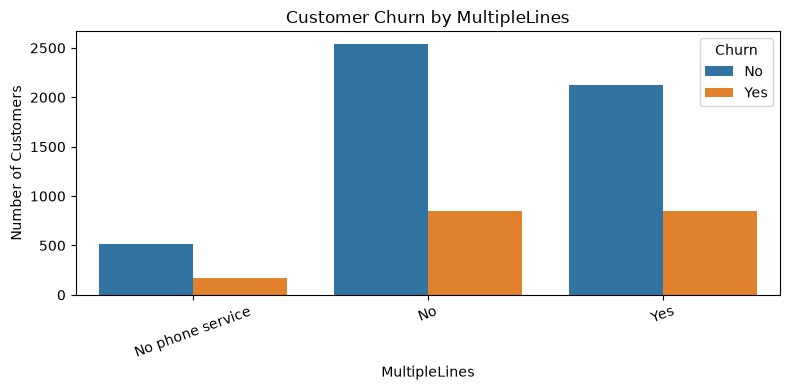

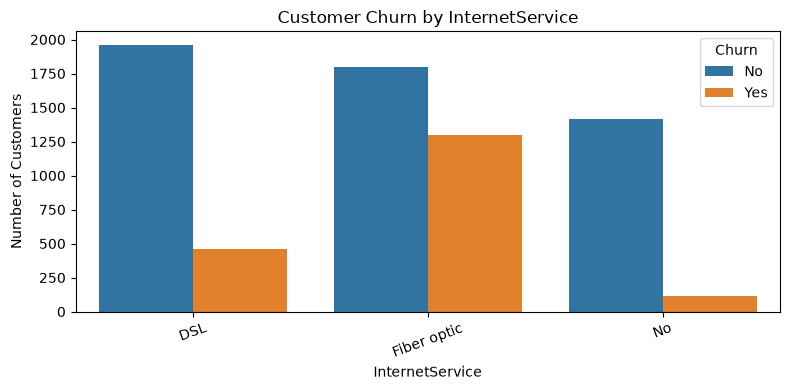

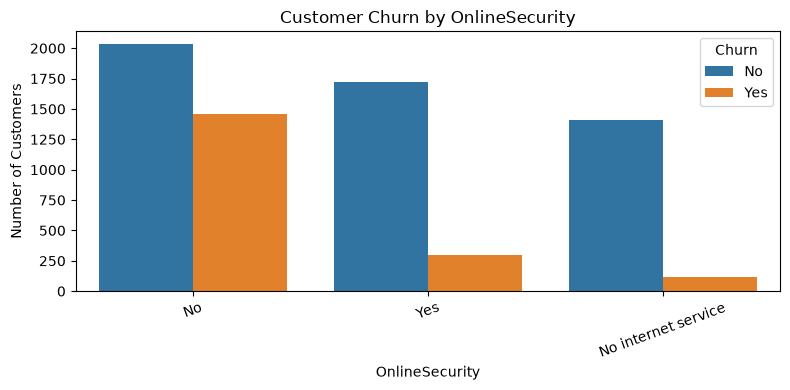

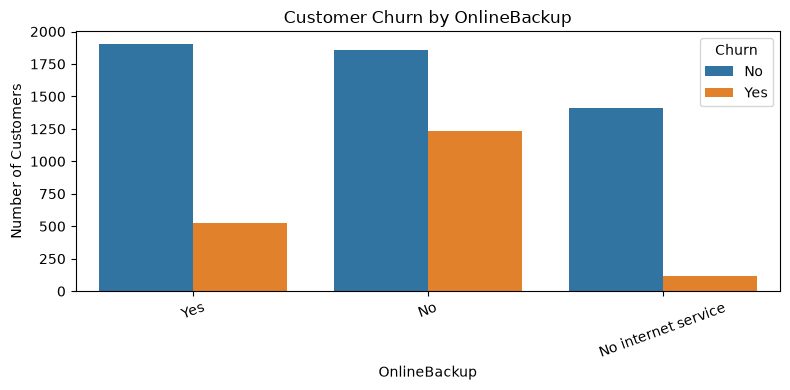

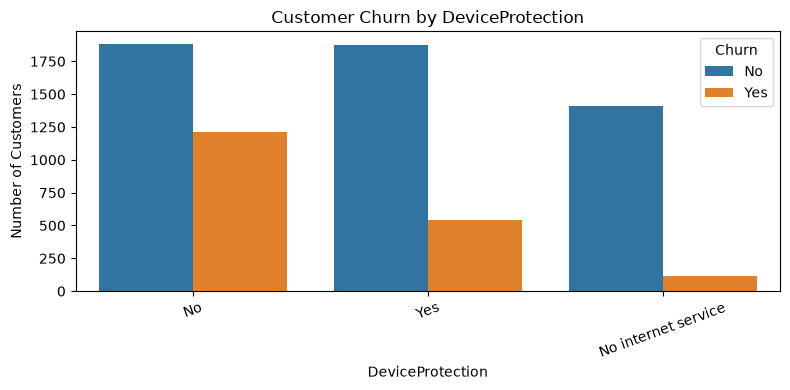

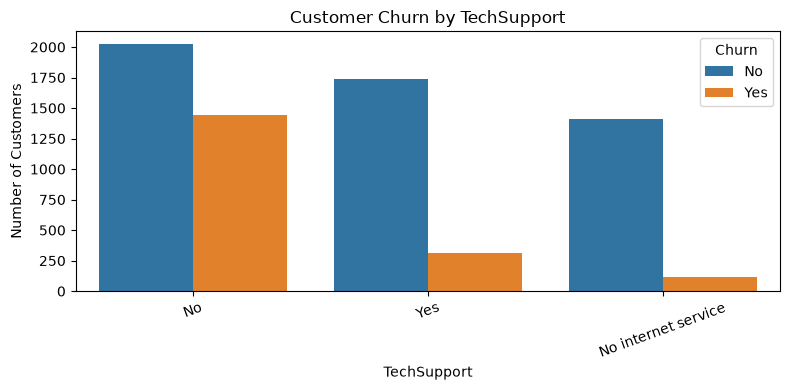

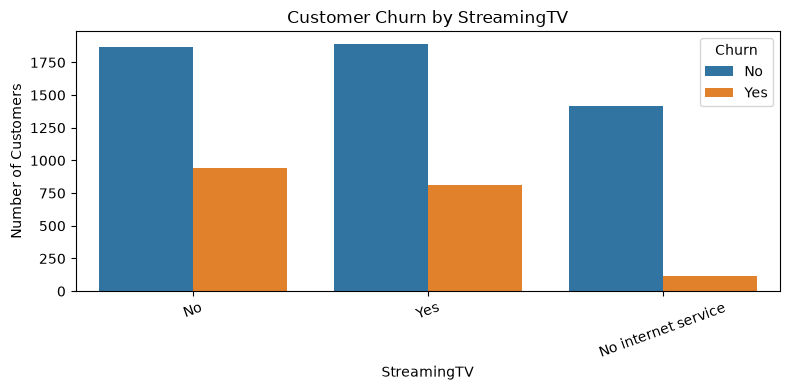

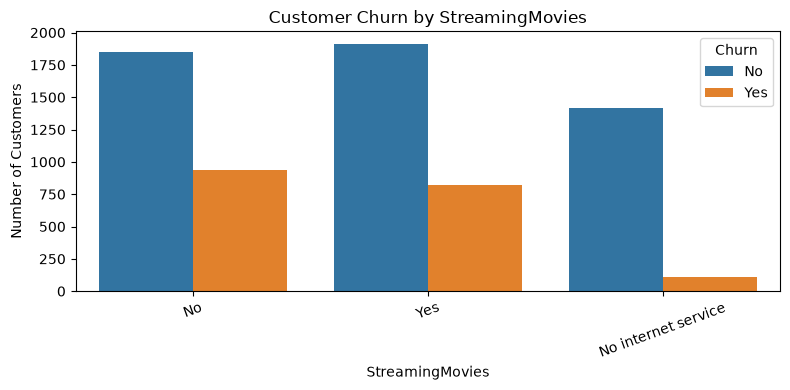

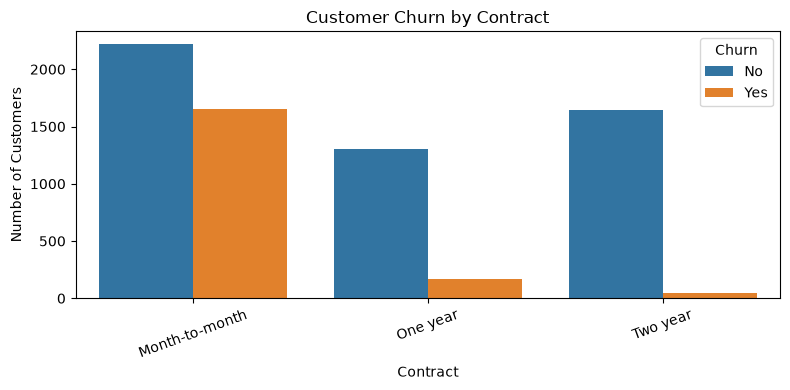

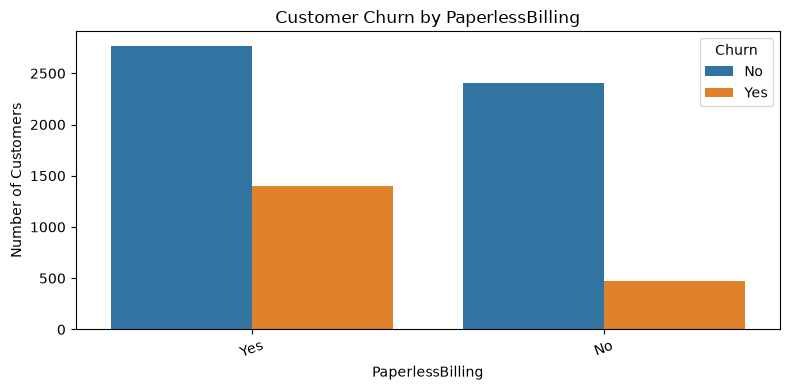

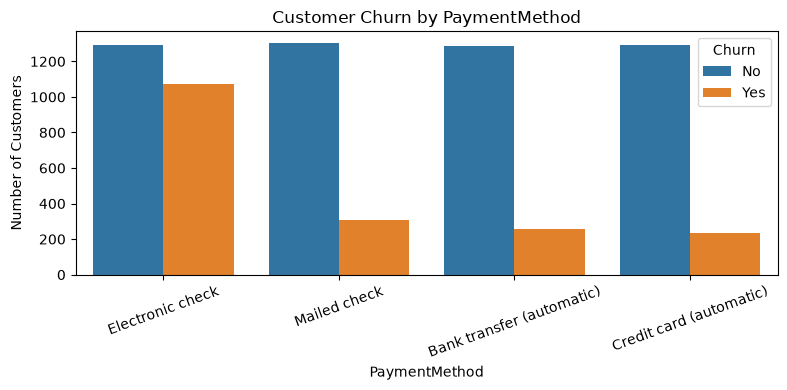

In [12]:
# Analyze churn across all categorical factors

categorical_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for column in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column, hue="Churn")
    
    plt.title(f"Customer Churn by {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [13]:
# Prepare data for machine learning

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)
print("Data prepared for machine learning!")

Features: (7043, 19)
Target: (7043,)
Data prepared for machine learning!


In [14]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 19)
Testing features: (1409, 19)
Training target: (5634,)
Testing target: (1409,)


In [15]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 5.9 MB/s eta 0:00:09
   -- ------------------------------------- 2.9/48.9 MB 8.6 MB/s eta 0:00:06
   -- ------------------------------------- 2.9/48.9 MB 8.6 MB/s eta 0:00:06
   -- ------------------------------------- 3.7/48.9 MB 5.3 MB/s eta 0:00:09
   --- ------------------------------------ 4.2/48.9 MB 4.1 MB/s eta 0:00:12
   --- ------------------------------------ 4.5/48.9 MB 4.2 MB/s eta 0:00:11
   ---- ----------------------------------- 5.0/48.9 MB 3.6 MB/s eta 0:00:13
   ---- ----------------------------------- 5.2/48.9 MB 3.1 MB/s eta 0:00:15
   ---- ----------------------------------- 5.8/48.9 MB 3.3 MB/s eta 0:00:13
   ----- ---------------------------------- 6.3/48.9 MB 3.0 MB/s eta 0:00:15
   ----- ---------------------------------- 6.8/48.9 MB 3.1 MB/s eta 0:00:14
   ----- ---------------------------------- 6.8/48.9 MB 3.1 MB/s eta 0:00:14
   ---


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# Create the 4 machine learning models

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            random_state=42,
            eval_metric="logloss"
        ))
    ])
}

print("4 models are ready!")

NameError: name 'preprocessor' is not defined

In [18]:
# Set up preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessing setup completed!")

Preprocessing setup completed!


C:\Users\sharm\AppData\Local\Temp\ipykernel_27124\4016637394.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [19]:
# Create the 4 machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            random_state=42,
            eval_metric="logloss"
        ))
    ])
}

print("4 models are ready!")

4 models are ready!


In [20]:
# Train all 4 models and evaluate their performance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Create comparison table
results_df = pd.DataFrame(results)

print("\nModel Performance Comparison:")
display(results_df.round(3))

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806,0.657,0.559,0.604,0.842
1,Decision Tree,0.798,0.635,0.567,0.599,0.830
2,Random Forest,0.775,0.598,0.465,0.523,0.819
3,XGBoost,0.807,0.673,0.529,0.593,0.844


In [21]:
# Feature Importance using XGBoost

# Get the trained XGBoost model
xgb_model = models["XGBoost"]

# Get the preprocessing step
preprocessor_fitted = xgb_model.named_steps["preprocessor"]

# Get the XGBoost model
xgb = xgb_model.named_steps["model"]

# Get feature names after encoding
feature_names = preprocessor_fitted.get_feature_names_out()

# Calculate feature importance
importance = pd.Series(
    xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Display top 15 important features
print("Top 15 factors influencing customer churn:")
display(importance.head(15))

Top 15 factors influencing customer churn:


cat__Contract_Month-to-month           0.543593
cat__InternetService_Fiber optic       0.123662
cat__OnlineSecurity_No                 0.036551
cat__TechSupport_No                    0.035456
cat__InternetService_DSL               0.022790
cat__StreamingMovies_Yes               0.018699
cat__Contract_Two year                 0.016951
cat__Contract_One year                 0.016674
num__tenure                            0.016385
cat__OnlineSecurity_Yes                0.015699
cat__PaymentMethod_Electronic check    0.013162
cat__MultipleLines_Yes                 0.012264
cat__PaperlessBilling_No               0.011416
cat__MultipleLines_No                  0.009727
cat__OnlineBackup_Yes                  0.008591
dtype: float32

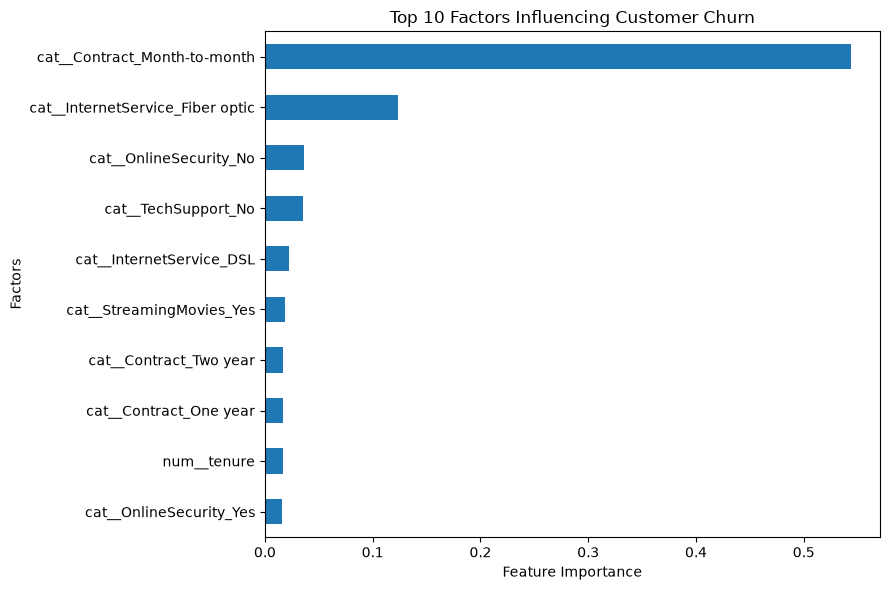

In [22]:
# Plot top 10 feature importance

top_features = importance.head(10).sort_values()

plt.figure(figsize=(9, 6))
top_features.plot(kind="barh")

plt.title("Top 10 Factors Influencing Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Factors")
plt.tight_layout()

plt.show()

In [23]:
# Customer Churn Risk Prediction

# Predict probability of churn for the test customers
churn_probability = models["XGBoost"].predict_proba(X_test)[:, 1]

# Create a risk score from 0 to 100
risk_score = churn_probability * 100

# Classify customers into risk levels
risk_level = []

for score in risk_score:
    if score < 30:
        risk_level.append("Low Risk")
    elif score < 60:
        risk_level.append("Medium Risk")
    else:
        risk_level.append("High Risk")

# Create a results table
risk_results = X_test.copy()
risk_results["Actual_Churn"] = y_test.values
risk_results["Churn_Probability"] = churn_probability.round(3)
risk_results["Risk_Score"] = risk_score.round(2)
risk_results["Risk_Level"] = risk_level

print("Customer churn risk prediction completed!")

display(
    risk_results[
        ["Contract", "InternetService", "tenure",
         "MonthlyCharges", "Churn_Probability",
         "Risk_Score", "Risk_Level"]
    ].head(10)
)

Customer churn risk prediction completed!


,Contract,InternetService,tenure,MonthlyCharges,Churn_Probability,Risk_Score,Risk_Level
437,Two year,Fiber optic,72,114.05,0.013,1.310000,Low Risk
2280,Month-to-month,Fiber optic,8,100.15,0.805,80.489998,High Risk
2235,One year,DSL,41,78.35,0.074,7.400000,Low Risk
4460,Month-to-month,Fiber optic,18,78.20,0.382,38.180000,Medium Risk
3761,Two year,DSL,72,82.65,0.005,0.530000,Low Risk
5748,Month-to-month,Fiber optic,21,99.85,0.590,58.980000,Medium Risk
3568,Month-to-month,Fiber optic,21,99.15,0.499,49.869999,Medium Risk
2976,Month-to-month,No,19,24.10,0.120,12.010000,Low Risk
5928,Two year,No,61,19.75,0.013,1.290000,Low Risk
1639,Month-to-month,DSL,17,45.05,0.342,34.180000,Medium Risk


Customer Risk Distribution:
Risk_Level
Low Risk       879
Medium Risk    337
High Risk      193
Name: count, dtype: int64


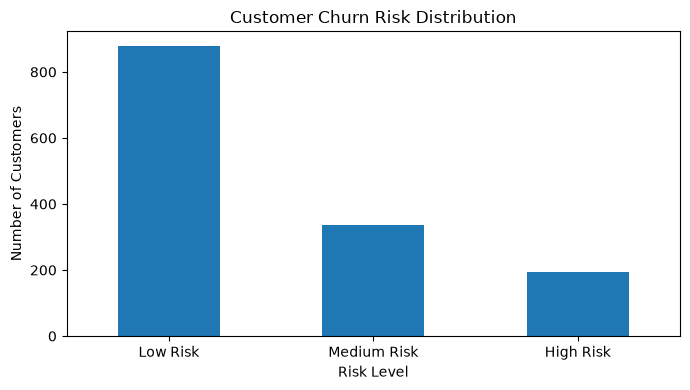

In [24]:
# Count customers in each churn-risk category

risk_counts = risk_results["Risk_Level"].value_counts()

print("Customer Risk Distribution:")
print(risk_counts)

# Plot risk distribution
plt.figure(figsize=(7, 4))
risk_counts.plot(kind="bar")

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [25]:
# Personalized retention recommendations

def retention_recommendation(row):
    if row["Contract"] == "Month-to-month":
        return "Offer a discounted long-term contract"
    
    elif row["TechSupport"] == "No" and row["InternetService"] == "Fiber optic":
        return "Offer technical support and service assistance"
    
    elif row["MonthlyCharges"] > df["MonthlyCharges"].median():
        return "Offer a personalized plan or billing discount"
    
    elif row["tenure"] < 12:
        return "Offer a new-customer loyalty benefit"
    
    else:
        return "Provide loyalty rewards and retention benefits"


risk_results["Retention_Recommendation"] = risk_results.apply(
    retention_recommendation,
    axis=1
)

print("Personalized retention recommendations created!")

display(
    risk_results[
        ["Contract", "InternetService", "tenure",
         "MonthlyCharges", "Risk_Level",
         "Retention_Recommendation"]
    ].head(10)
)


Personalized retention recommendations created!


,Contract,InternetService,tenure,MonthlyCharges,Risk_Level,Retention_Recommendation
437,Two year,Fiber optic,72,114.05,Low Risk,Offer a personalized plan or billing discount
2280,Month-to-month,Fiber optic,8,100.15,High Risk,Offer a discounted long-term contract
2235,One year,DSL,41,78.35,Low Risk,Offer a personalized plan or billing discount
4460,Month-to-month,Fiber optic,18,78.20,Medium Risk,Offer a discounted long-term contract
3761,Two year,DSL,72,82.65,Low Risk,Offer a personalized plan or billing discount
5748,Month-to-month,Fiber optic,21,99.85,Medium Risk,Offer a discounted long-term contract
3568,Month-to-month,Fiber optic,21,99.15,Medium Risk,Offer a discounted long-term contract
2976,Month-to-month,No,19,24.10,Low Risk,Offer a discounted long-term contract
5928,Two year,No,61,19.75,Low Risk,Provide loyalty rewards and retention benefits
1639,Month-to-month,DSL,17,45.05,Medium Risk,Offer a discounted long-term contract


In [26]:
# Final Customer Churn Risk System for all customers

all_churn_probability = models["XGBoost"].predict_proba(X)[:, 1]

all_risk_score = all_churn_probability * 100

all_risk_level = []

for score in all_risk_score:
    if score < 30:
        all_risk_level.append("Low Risk")
    elif score < 60:
        all_risk_level.append("Medium Risk")
    else:
        all_risk_level.append("High Risk")

final_risk = X.copy()

final_risk["Churn_Probability"] = all_churn_probability.round(3)
final_risk["Risk_Score"] = all_risk_score.round(2)
final_risk["Risk_Level"] = all_risk_level

print("Risk prediction completed for all customers!")
print("Total customers:", len(final_risk))

print("\nRisk Distribution:")
print(final_risk["Risk_Level"].value_counts())

display(
    final_risk[
        ["Contract", "InternetService", "tenure",
         "MonthlyCharges", "Churn_Probability",
         "Risk_Score", "Risk_Level"]
    ].head(10)
)

Risk prediction completed for all customers!
Total customers: 7043

Risk Distribution:
Risk_Level
Low Risk       4416
Medium Risk    1613
High Risk      1014
Name: count, dtype: int64


,Contract,InternetService,tenure,MonthlyCharges,Churn_Probability,Risk_Score,Risk_Level
0,Month-to-month,DSL,1,29.85,0.666,66.639999,High Risk
1,One year,DSL,34,56.95,0.031,3.070000,Low Risk
2,Month-to-month,DSL,2,53.85,0.421,42.130001,Medium Risk
3,One year,DSL,45,42.30,0.032,3.220000,Low Risk
4,Month-to-month,Fiber optic,2,70.70,0.618,61.830002,High Risk
5,Month-to-month,Fiber optic,8,99.65,0.866,86.559998,High Risk
6,Month-to-month,Fiber optic,22,89.10,0.343,34.250000,Medium Risk
7,Month-to-month,DSL,10,29.75,0.175,17.510000,Low Risk
8,Month-to-month,Fiber optic,28,104.80,0.636,63.599998,High Risk
9,One year,DSL,62,56.15,0.019,1.900000,Low Risk


In [27]:
# Calculate Retention Priority Score

final_risk["Retention_Priority_Score"] = (
    final_risk["Churn_Probability"] * final_risk["MonthlyCharges"]
)

# Rank customers by retention priority
priority_customers = final_risk.sort_values(
    "Retention_Priority_Score",
    ascending=False
)

print("Top 10 customers requiring retention attention:")

display(
    priority_customers[
        ["Contract", "InternetService", "tenure",
         "MonthlyCharges", "Churn_Probability",
         "Risk_Level", "Retention_Priority_Score"]
    ].head(10)
)

Top 10 customers requiring retention attention:


,Contract,InternetService,tenure,MonthlyCharges,Churn_Probability,Risk_Level,Retention_Priority_Score
6482,Month-to-month,Fiber optic,1,101.45,0.938,High Risk,95.160102
2208,Month-to-month,Fiber optic,1,100.80,0.940,High Risk,94.752000
1704,Month-to-month,Fiber optic,1,99.75,0.937,High Risk,93.465748
4459,Month-to-month,Fiber optic,1,100.25,0.914,High Risk,91.628497
2246,Month-to-month,Fiber optic,1,102.45,0.894,High Risk,91.590299
4517,Month-to-month,Fiber optic,11,99.55,0.917,High Risk,91.287350
3349,Month-to-month,Fiber optic,11,99.50,0.913,High Risk,90.843499
5874,Month-to-month,Fiber optic,10,100.60,0.900,High Risk,90.539998
1132,Month-to-month,Fiber optic,11,104.05,0.862,High Risk,89.691099
6839,Month-to-month,Fiber optic,11,100.75,0.889,High Risk,89.566750


In [28]:
# Save important project outputs

results_df.to_csv("outputs/model_comparison.csv", index=False)
final_risk.to_csv("outputs/final_customer_risk.csv", index=False)
importance.head(15).to_csv("outputs/feature_importance.csv")

print("Project outputs saved successfully!")

Project outputs saved successfully!


In [29]:
# Final model comparison

print("FINAL MODEL PERFORMANCE")
display(results_df.round(3))

FINAL MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806,0.657,0.559,0.604,0.842
1,Decision Tree,0.798,0.635,0.567,0.599,0.830
2,Random Forest,0.775,0.598,0.465,0.523,0.819
3,XGBoost,0.807,0.673,0.529,0.593,0.844


In [30]:
import joblib
import os

# Create a folder for saved models
os.makedirs("outputs/models", exist_ok=True)

# Save all four trained models
for name, model in models.items():
    filename = name.lower().replace(" ", "_") + ".pkl"
    joblib.dump(model, f"outputs/models/{filename}")

print("All models saved successfully!")

All models saved successfully!


In [31]:
# Test the model on a new customer

new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 90.0,
    "TotalCharges": 450.0
}])

# Predict churn probability
probability = models["XGBoost"].predict_proba(new_customer)[0][1]

# Convert probability to Yes/No
prediction = "Yes" if probability >= 0.5 else "No"

# Assign risk level
if probability < 0.30:
    risk = "Low Risk"
elif probability < 0.60:
    risk = "Medium Risk"
else:
    risk = "High Risk"

print("----- NEW CUSTOMER PREDICTION -----")
print("Churn Prediction:", prediction)
print("Churn Probability:", round(probability * 100, 2), "%")
print("Risk Level:", risk)

----- NEW CUSTOMER PREDICTION -----
Churn Prediction: Yes
Churn Probability: 74.6 %
Risk Level: High Risk
